In [126]:
import numpy as np
import input_parameters as parmt
import matplotlib.pyplot as plt
import matplotlib.colors
from epsilon_routines import epsilon_r
from binning import gen_bin_centers

#%matplotlib inline

mElectron = 5.1099894e5
alpha = 1.0/137.03599908

q = np.arange(0.01, 1, parmt.dq) #alpha me
E = np.arange(0, 200+parmt.dE, parmt.dE) #eV

In [165]:
#RPA
binned_eps = np.load('test_resources/epsilon_1q_200E_tz_6/binned_eps.npy') #6x6x6 -> 6x6x6
bin_centers = gen_bin_centers(q_max=1)
eps = epsilon_r(bin_centers, binned_eps)

binned_eps = np.load('test_resources/epsilon_1q_50E_tz_46/binned_eps.npy') #4x4x4 -> 6x6x6
bin_centers = gen_bin_centers(q_max=1)
eps_46 = epsilon_r(bin_centers, binned_eps)

In [124]:
#RPA Kramers-Kronig 
from scipy.ndimage import gaussian_filter1d

def kk_1d(eps, E, n_q, corr=False):
    eps_im = np.imag(eps[n_q,:])
    eps_re = np.zeros_like(eps_im)
    for n, En in enumerate(E):
        E_pv = np.delete(E, n) #removes Ei = En for principal value
        eps_re[n] = 2/np.pi*parmt.dE*(sum([Ei*eps_im[i]/(Ei**2-En**2) for i,Ei in enumerate(E_pv)]) - 0.5*(E_pv[0]*eps_im[0]/(E_pv[0]**2-En**2) + E_pv[-1]*eps_im[-1]/(E_pv[-1]**2-En**2)))#trapezoid rule
    if corr:
        eps_re = eps_re*4*np.pi
    return eps_re + 1

def kk_2d(eps, E, n_E, corr=False):
    eps_im = np.imag(eps)
    if filter:
        for q_i in range(eps.shape[0]): #for each q
            eps_im[q_i,:] = gaussian_filter1d(eps_im[q_i,:],10)

    eps_re = np.zeros((eps_im.shape[0], n_E))
    for n, En in enumerate(E[:n_E]):
        E_pv = np.delete(E, n) #removes Ei = En for principal value
        eps_im_pv = np.delete(eps_im, n, axis=1)

        eps_re[:,n] = 2/np.pi*parmt.dE*(np.sum(E_pv[None,:] * eps_im_pv / (E_pv[None,:]**2 - En**2), axis=1) - 0.5*(E_pv[None,0]*eps_im_pv[:,0]/(E_pv[None,0]**2-En**2) + E_pv[None,-1]*eps_im_pv[:,-1]/(E_pv[None,-1]**2-En**2))) #trapezoid rule
    if corr:
        eps_re = eps_re*4*np.pi
    return eps_re + 1


In [4]:
#DarkELF
import sys
import os
sys.path.append(os.getcwd()+'/../DarkELF')
from darkelf import darkelf, targets

darkelf_gpaw = darkelf(target='Si', filename='Si_gpaw_noLFE.dat')

 .... Loading files for Si
Loaded Si_gpaw_noLFE.dat for epsilon in electron regime
electronic ELF taken or calculated from J. Enkovaara et al.,Electronic structure calculations with GPAW: a real-space implementation of the projector augmented-wave method,Journal of Physics:Condensed Matter22(2010) 253202.
phonon ELF taken or calculated from M. Ikezawa and M. Ishigame, Far-Infrared AbsorptionDue to the Two-Phonon Difference Process in Si, Journal of the Physical Society of Japan 50(1981) 3734.
Loaded Si_epsphonon_data6K.dat for epsilon in phonon regime
Zion(k) for Migdal calculation taken or calculated from: P. J. Brown, A. G. Fox, E. N. Maslen, M. A. OKeefe,and B. T. M. Willis, “Intensity of diffracted intensities,” in International Tables for Crystallography (American Cancer Society, 2006) Chap. 6.1, pp. 554–595, https://onlinelibrary.wiley.com/doi/pdf/10.1107/97809553602060000
Loaded /home/meganhott/Research/dielectric_pyscf/../DarkELF/darkelf/../data/Si/Si_pDoS.dat for partial densi

In [127]:
#Lindhard model
VCell = 5.209e-9
nValence = 8
MCell = 52322355000.0
mElectron = 5.1099894e5
alpha = 1.0/137.03599908

def Lindhard(om, q, fp): #energy, q, 
    q = q*alpha*mElectron #convert q from ame to eV
    def plog(x):
        return np.log(np.abs(x)) + 1j*np.angle(x)
    ne = nValence/VCell
    kF = (3*np.pi**2*ne)**(1./3.)
    omp = np.sqrt(4*np.pi*alpha*ne/mElectron)
    vF = kF/mElectron
    Gp = fp*omp
    Qp = q/(2*kF) + (om + 1j*Gp)/(q*vF)
    Qm = q/(2*kF) - (om + 1j*Gp)/(q*vF)
    factor1 = 3*(omp**2)/(q**2)/(vF**2)
    factor2 = 0.5 + kF/(4*q)*(1-Qm**2)*plog((Qm+1)/(Qm-1)) + kF/(4*q)*(1-Qp**2)*plog((Qp+1)/(Qp-1))
    return 1 + factor1*factor2

E_mesh, q_mesh = np.meshgrid(E, q)
eps_l = Lindhard(E_mesh, q_mesh, 0.1)

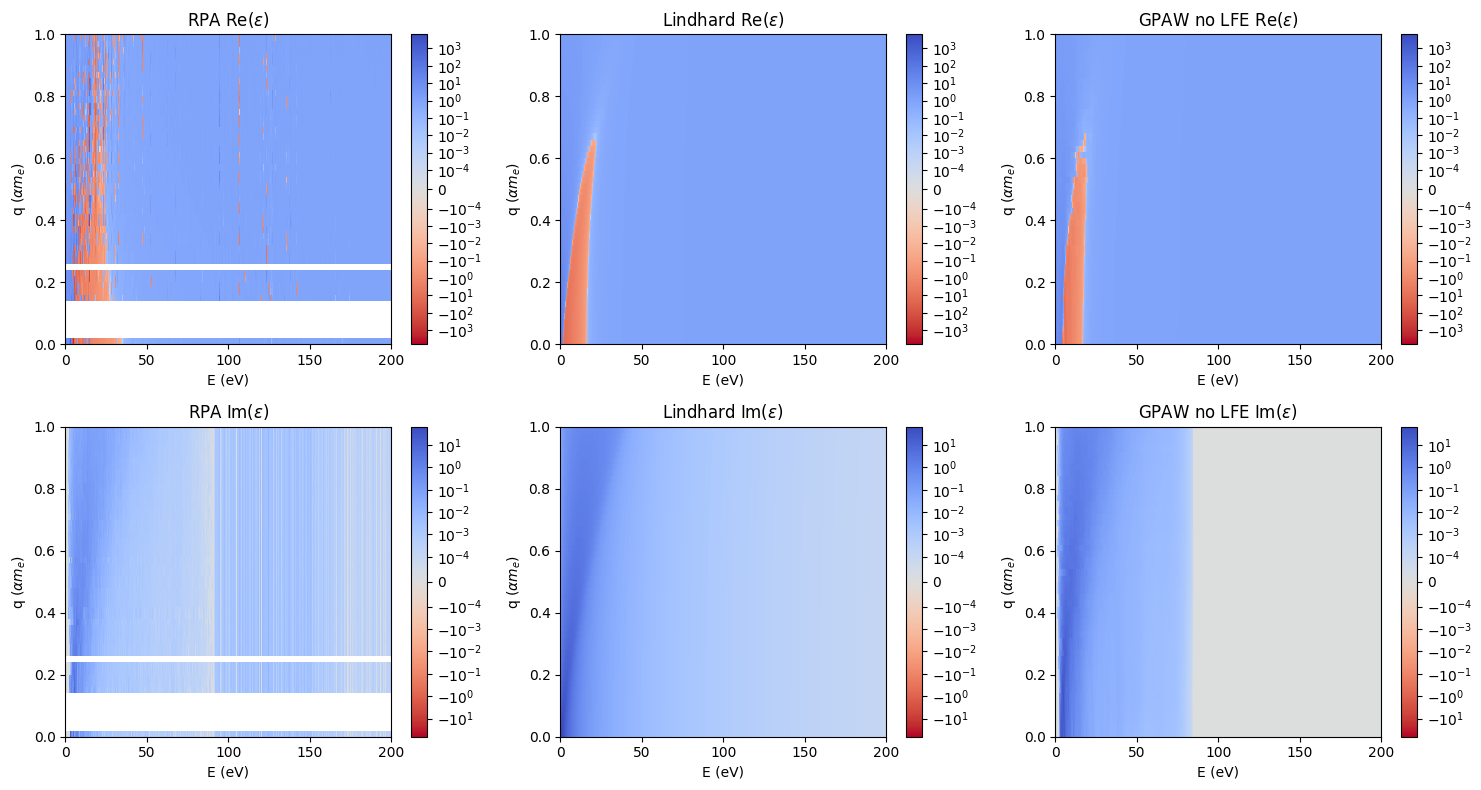

In [128]:
#Full Re and Im Plots
c = 'coolwarm_r'
th = 1e-4
re_min = np.min(np.concatenate([np.real(eps[np.invert(np.isnan(eps))]), np.real(eps_l[np.invert(np.isnan(eps_l))])]))
re_max = np.max(np.concatenate([np.real(eps[np.invert(np.isnan(eps))]), np.real(eps_l[np.invert(np.isnan(eps_l))])]))
im_min = np.min(np.concatenate([np.imag(eps[np.invert(np.isnan(eps))]), np.imag(eps_l[np.invert(np.isnan(eps_l))])]))
im_max = np.max(np.concatenate([np.imag(eps[np.invert(np.isnan(eps))]), np.imag(eps_l[np.invert(np.isnan(eps_l))])]))
re_max = max(-1*re_min, re_max)

fig, ax = plt.subplots(2,3, figsize=(15,8))

im0 = ax[(0,0)].pcolormesh(E, q, np.real(eps), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im1 = ax[(1,0)].pcolormesh(E, q, np.imag(eps), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-im_max, vmax=im_max,))
im2 = ax[(0,1)].pcolormesh(E, q, np.real(eps_l), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im3 = ax[(1,1)].pcolormesh(E, q, np.imag(eps_l), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-im_max, vmax=im_max,))
im4 = ax[(0,2)].pcolormesh(E, q, darkelf_gpaw.eps1(E, q*alpha*mElectron), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im5 = ax[(1,2)].pcolormesh(E, q, darkelf_gpaw.eps2(E, q*alpha*mElectron), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-im_max, vmax=im_max))
"""
im0 = ax[(0,0)].imshow(np.real(eps_l), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max), origin='lower')
im1 = ax[(0,1)].imshow(np.imag(eps_l), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-im_max, vmax=im_max,), origin='lower')
im2 = ax[(1,0)].imshow(np.real(eps), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max), origin='lower')
im3 = ax[(1,1)].imshow(np.imag(eps), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-im_max, vmax=im_max,), origin='lower')
"""
fig.colorbar(im0, ax=ax[(0,0)])
fig.colorbar(im1, ax=ax[(1,0)])
ax[(0,0)].set_title(r'RPA Re($\epsilon$)')
ax[(1,0)].set_title(r'RPA Im($\epsilon$)')
#ax[(1,0)].axvline(x=1.12, ymin=0, ymax=1, color='k', linestyle='--')
fig.colorbar(im2, ax=ax[(0,1)])
fig.colorbar(im3, ax=ax[(1,1)])
ax[(0,1)].set_title(r'Lindhard Re($\epsilon$)')
ax[(1,1)].set_title(r'Lindhard Im($\epsilon$)')
fig.colorbar(im4, ax=ax[(0,2)])
fig.colorbar(im5, ax=ax[(1,2)])
ax[(0,2)].set_title(r'GPAW no LFE Re($\epsilon$)')
ax[(1,2)].set_title(r'GPAW no LFE Im($\epsilon$)')

for i in [0,1]:
    for j in [0,1,2]:
        ax[(i,j)].set_xlabel('E (eV)')
        ax[(i,j)].set_ylabel(r'q ($\alpha m_e$)')
plt.tight_layout()

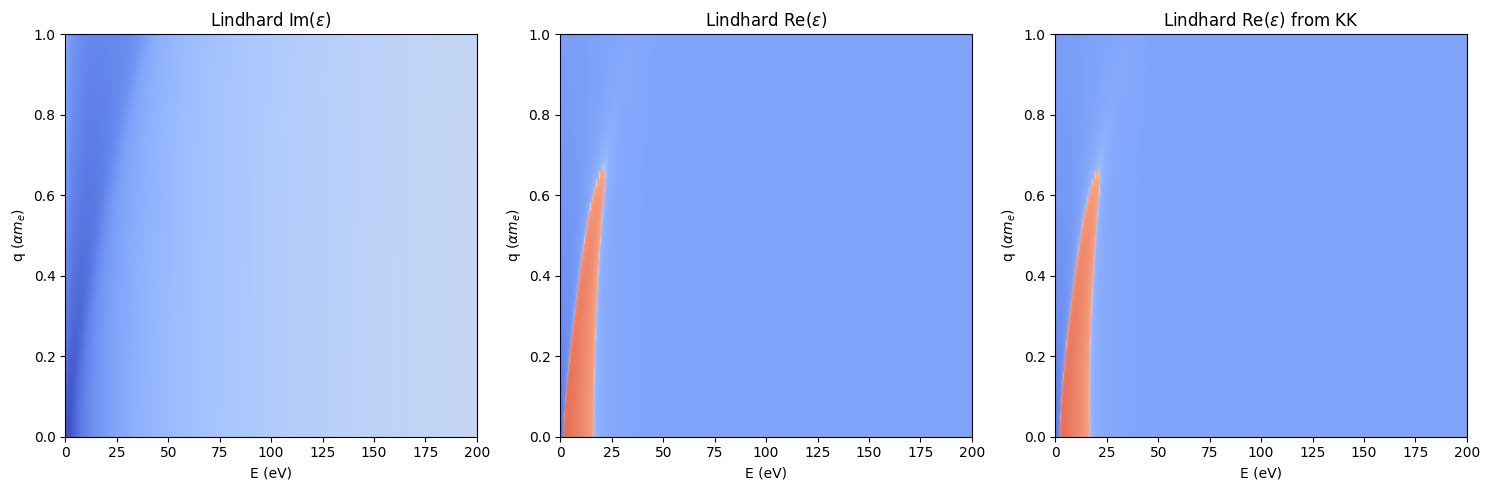

In [130]:
#Testing Kramers-Kronig with Lindhard

E_l = np.arange(0, 500+parmt.dE, parmt.dE)
E_mesh_l, q_mesh_l = np.meshgrid(E_l, q)
eps_l_large = Lindhard(E_mesh_l, q_mesh_l, 0.1)

eps_kk_l_re = kk_2d(eps_l, E, E.shape[0]) #still looks accurate only inlcuding energies up to 50eV

fig, ax = plt.subplots(1,3, figsize=(15,5))
im0 = ax[0].pcolormesh(E, q, np.imag(eps_l), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-im_max, vmax=im_max))
im1 = ax[1].pcolormesh(E, q, np.real(eps_l), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im2 = ax[2].pcolormesh(E, q, eps_kk_l_re[:,:E.shape[0]], cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))

ax[0].set_title(r'Lindhard Im($\epsilon$)')
ax[1].set_title(r'Lindhard Re($\epsilon$)')
ax[2].set_title(r'Lindhard Re($\epsilon$) from KK')
for i in [0,1,2]:
    ax[i].set_xlabel('E (eV)')
    ax[i].set_ylabel(r'q ($\alpha m_e$)')
plt.tight_layout()

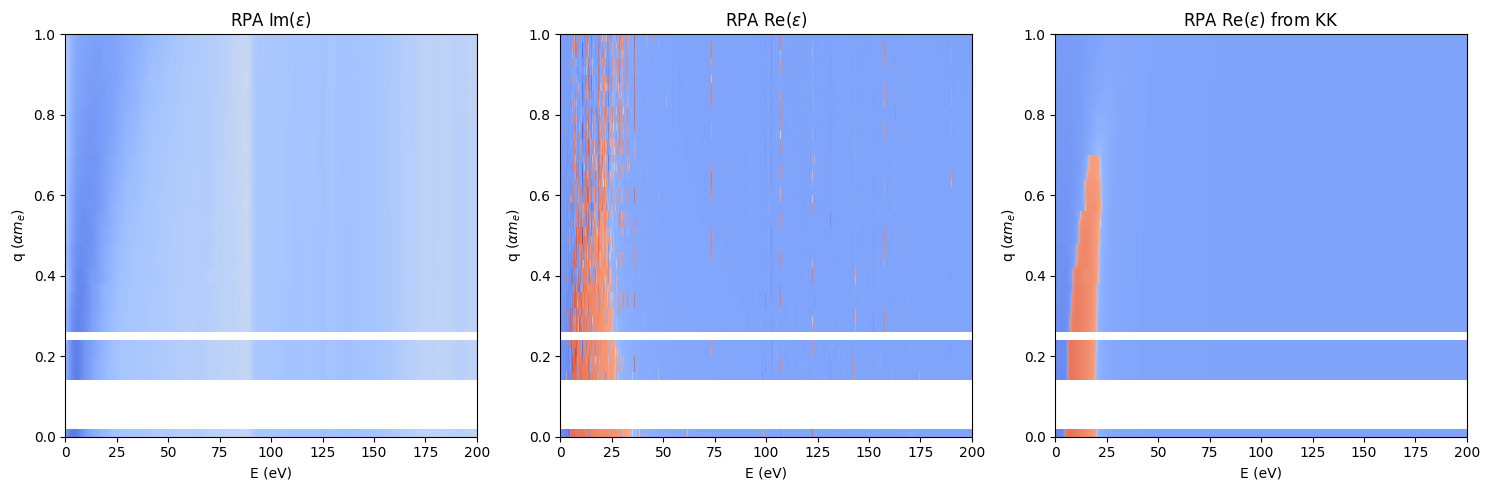

In [139]:
#Kramers-Kronig RPA
eps_kk_re = kk_2d(eps, E, E.shape[0], corr=True)

fig, ax = plt.subplots(1,3, figsize=(15,5))
im0 = ax[0].pcolormesh(E, q, np.imag(eps), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-im_max, vmax=im_max))
im1 = ax[1].pcolormesh(E, q, np.real(eps), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im2 = ax[2].pcolormesh(E, q, eps_kk_re, cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
#Note modification to Re from KK in last plot - could we get something reasonable if constant multiplying chi is fixed?

ax[0].set_title(r'RPA Im($\epsilon$)')
ax[1].set_title(r'RPA Re($\epsilon$)')
ax[2].set_title(r'RPA Re($\epsilon$) from KK')
for i in [0,1,2]:
    ax[i].set_xlabel('E (eV)')
    ax[i].set_ylabel(r'q ($\alpha m_e$)')
plt.tight_layout()

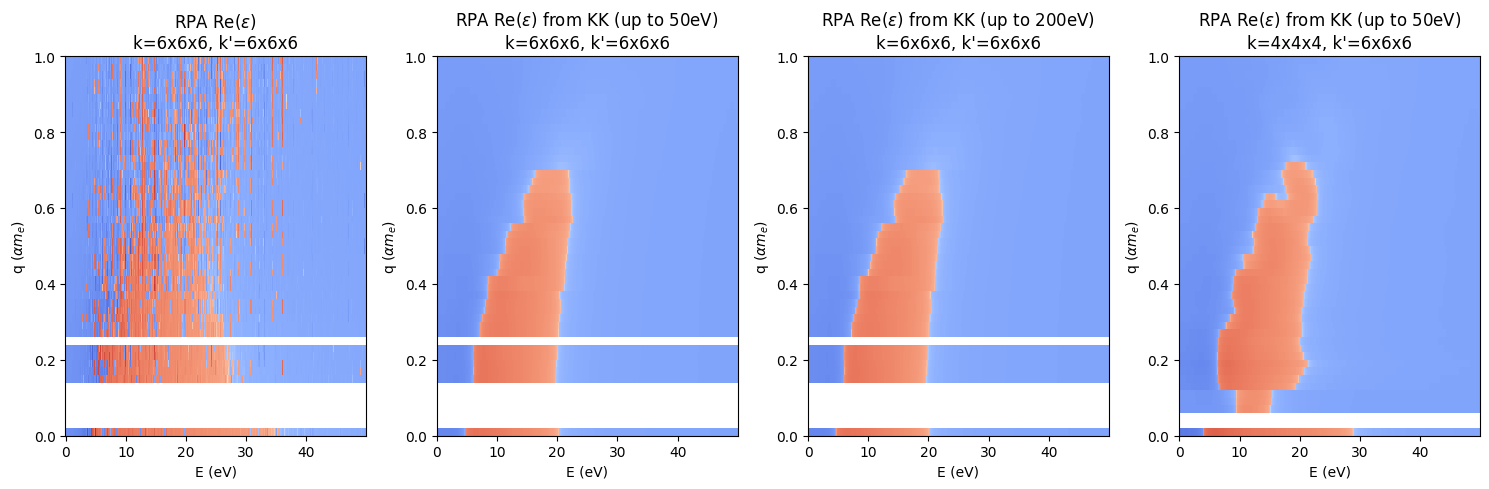

In [167]:
#Kramers-Kronig RPA
eps_kk_re_50 = kk_2d(eps[:,:501], E[:501], 500, corr=True) #only using data up to 50eV in KK
eps_kk_re_46 = kk_2d(eps_46, E[:501], 500, corr=True) 

fig, ax = plt.subplots(1, 4, figsize=(15,5))
im0 = ax[0].pcolormesh(E[:int(50/parmt.dE)], q, np.real(eps[:,:int(50/parmt.dE)]), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im1 = ax[1].pcolormesh(E[:int(50/parmt.dE)], q, eps_kk_re_50, cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im2 = ax[2].pcolormesh(E[:int(50/parmt.dE)], q, eps_kk_re[:,:int(50/parmt.dE)], cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im3 = ax[3].pcolormesh(E[:int(50/parmt.dE)], q, eps_kk_re_46, cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))

ax[0].set_title(r'RPA Re($\epsilon$)'+'\n'+"k=6x6x6, k'=6x6x6")
ax[1].set_title(r'RPA Re($\epsilon$) from KK (up to 50eV)'+'\n'+"k=6x6x6, k'=6x6x6")
ax[2].set_title(r'RPA Re($\epsilon$) from KK (up to 200eV)'+'\n'+"k=6x6x6, k'=6x6x6")
ax[3].set_title(r'RPA Re($\epsilon$) from KK (up to 50eV)'+'\n'+"k=4x4x4, k'=6x6x6")
for i in [0,1,2,3]:
    ax[i].set_xlabel('E (eV)')
    ax[i].set_ylabel(r'q ($\alpha m_e$)')
plt.tight_layout()

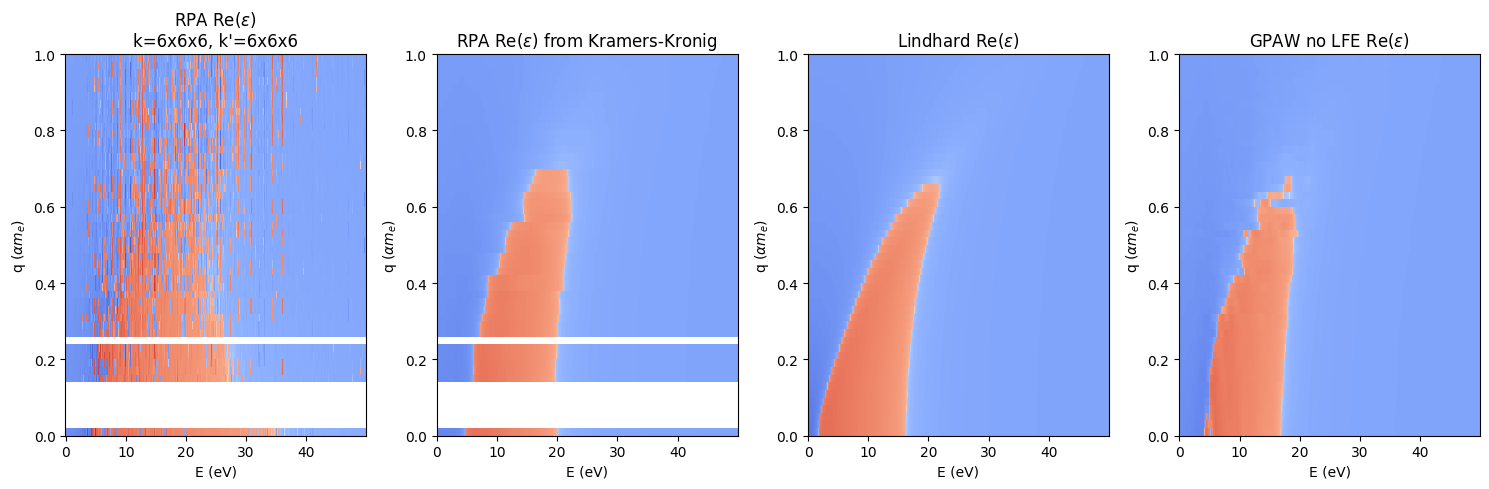

In [160]:
#Comparing Re(RPA)
fig, ax = plt.subplots(1, 4, figsize=(15,5))
im0 = ax[0].pcolormesh(E[:int(50/parmt.dE)], q, np.real(eps[:,:int(50/parmt.dE)]), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im1 = ax[1].pcolormesh(E[:int(50/parmt.dE)], q, eps_kk_re[:,:int(50/parmt.dE)], cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im2 = ax[2].pcolormesh(E[:int(50/parmt.dE)], q, np.real(eps_l[:,:int(50/parmt.dE)]), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max,))
im3 = ax[3].pcolormesh(E[:int(50/parmt.dE)], q, darkelf_gpaw.eps1(E[:int(50/parmt.dE)], q*alpha*mElectron), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))

ax[0].set_title(r'RPA Re($\epsilon$)'+'\n'+"k=6x6x6, k'=6x6x6")
ax[1].set_title(r'RPA Re($\epsilon$) from Kramers-Kronig')
ax[2].set_title(r'Lindhard Re($\epsilon$)')
ax[3].set_title(r'GPAW no LFE Re($\epsilon$)')
for i in [0,1,2,3]:
    ax[i].set_xlabel('E (eV)')
    ax[i].set_ylabel(r'q ($\alpha m_e$)')
plt.tight_layout()

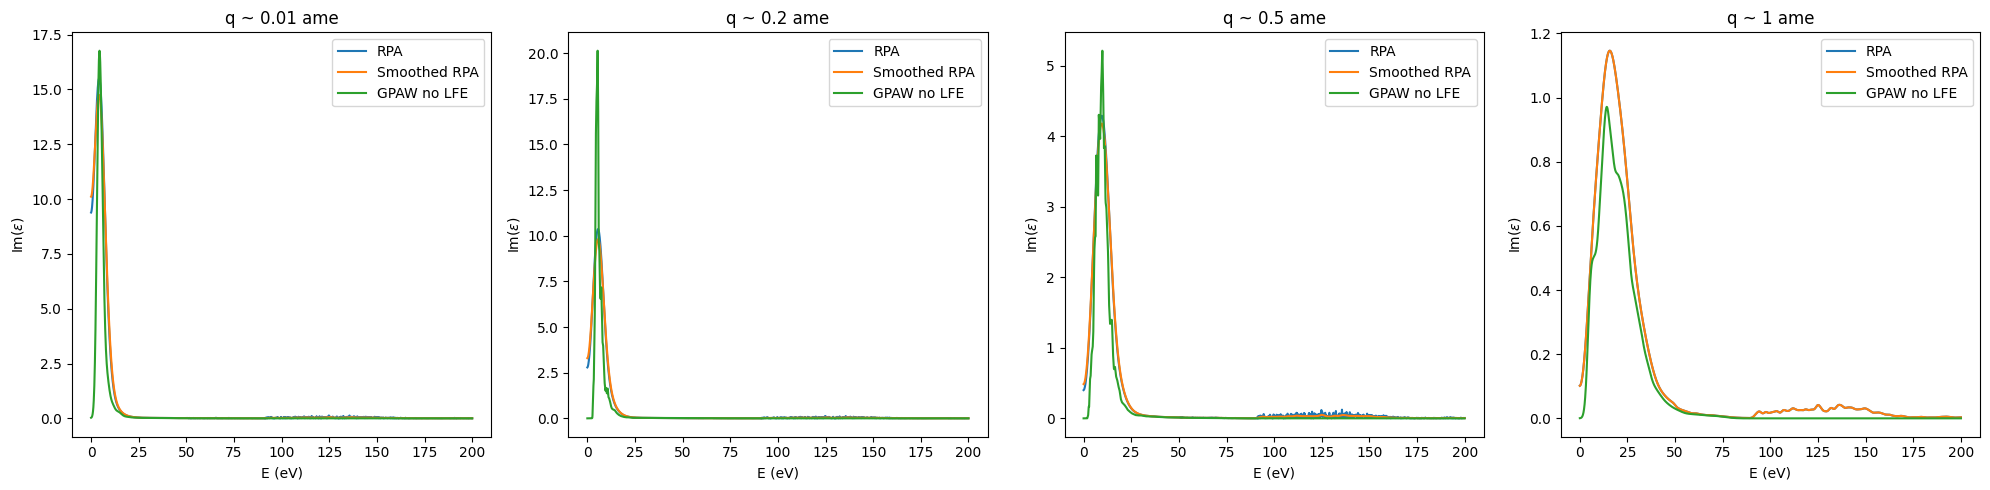

In [162]:
#Im plots
from scipy.ndimage import gaussian_filter1d

#Nonlinear factor to make RPA match GPAW and Lindhard

fig, ax = plt.subplots(1,4, figsize=(20,5))
ax[0].plot(E, 4*np.pi*np.imag(eps[0,:]), label='RPA')
ax[0].plot(E, 4*np.pi*gaussian_filter1d(np.imag(eps[0,:]),10), label='Smoothed RPA')
ax[0].plot(E, gaussian_filter1d(darkelf_gpaw.eps2(E, 0.01*alpha*mElectron),10), label='GPAW no LFE')
#ax[0].plot(E, np.imag(eps_l[0,:]), label='Lindhard')
ax[0].set_title('q ~ 0.01 ame')
ax[0].legend()

ax[1].plot(E, 4*np.pi*np.imag(eps[10,:]), label='RPA')
ax[1].plot(E, 4*np.pi*gaussian_filter1d(np.imag(eps[10,:]),10), label='Smoothed RPA')
ax[1].plot(E, darkelf_gpaw.eps2(E, 0.2*alpha*mElectron), label='GPAW no LFE')
#ax[1].plot(E, np.imag(eps_l[25,:]), label='Lindhard')
ax[1].set_title('q ~ 0.2 ame')
ax[1].legend()

ax[2].plot(E, 4*np.pi*np.imag(eps[25,:]), label='RPA')
ax[2].plot(E, 4*np.pi*gaussian_filter1d(np.imag(eps[25,:]),10), label='Smoothed RPA')
ax[2].plot(E, darkelf_gpaw.eps2(E, 0.5*alpha*mElectron), label='GPAW no LFE')
#ax[1].plot(E, np.imag(eps_l[25,:]), label='Lindhard')
ax[2].set_title('q ~ 0.5 ame')
ax[2].legend()

ax[3].plot(E, 4*np.pi*gaussian_filter1d(np.imag(eps[-1,:]),10), label='RPA')
ax[3].plot(E, 4*np.pi*gaussian_filter1d(np.imag(eps[-1,:]),10), label='Smoothed RPA')
ax[3].plot(E, gaussian_filter1d(darkelf_gpaw.eps2(E, 1*alpha*mElectron),10), label='GPAW no LFE')
#ax[2].plot(E, np.imag(eps_l[-1,:]), label='Lindhard')
ax[3].set_title('q ~ 1 ame')
ax[3].legend()

for i in [0,1,2,3]:
    ax[i].set_xlabel('E (eV)')
    ax[i].set_ylabel(r'Im($\epsilon)$')
plt.tight_layout()
plt.show()


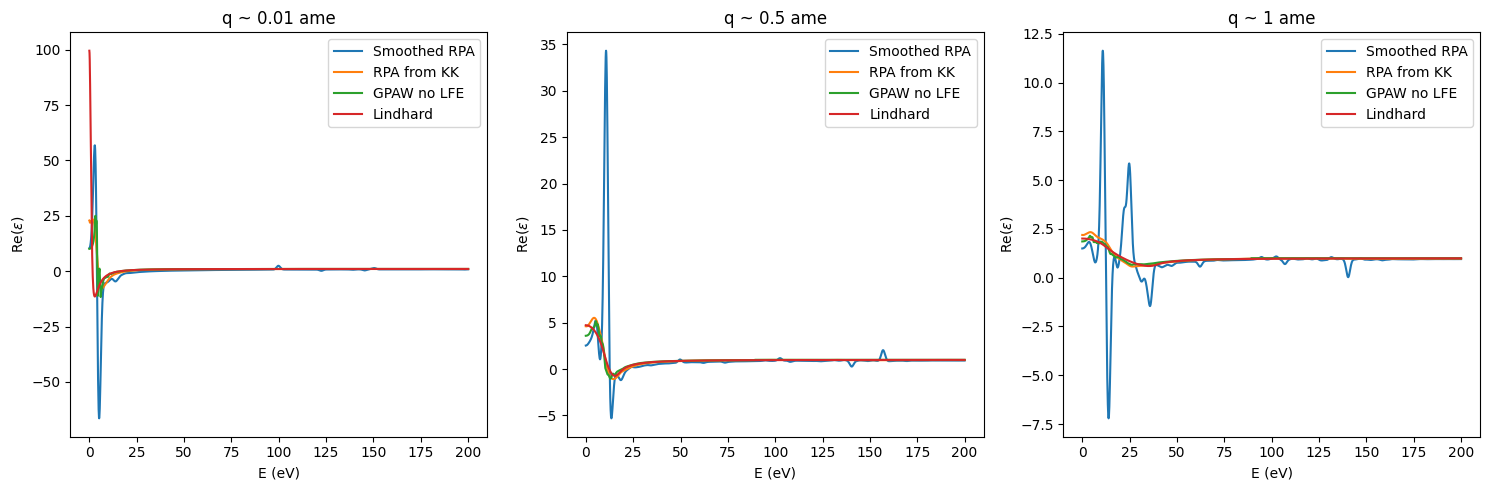

In [142]:
#Re plots

fig, ax = plt.subplots(1,3, figsize=(15,5))
ax[0].plot(E, gaussian_filter1d(np.real(eps[0,:]),10), label='Smoothed RPA')
ax[0].plot(E, eps_kk_re[0], label='RPA from KK')
ax[0].plot(E, darkelf_gpaw.eps1(E, 0.01*alpha*mElectron), label='GPAW no LFE')
ax[0].plot(E, np.real(eps_l[0,:]), label='Lindhard')
ax[0].set_title('q ~ 0.01 ame')
ax[0].legend()

ax[1].plot(E, gaussian_filter1d(np.real(eps[25,:]),10), label='Smoothed RPA')
ax[1].plot(E, eps_kk_re[25], label='RPA from KK') 
ax[1].plot(E, darkelf_gpaw.eps1(E, 0.5*alpha*mElectron), label='GPAW no LFE')
ax[1].plot(E, np.real(eps_l[25,:]), label='Lindhard')
ax[1].set_title('q ~ 0.5 ame')
ax[1].legend()

ax[2].plot(E, gaussian_filter1d(np.real(eps[25,:]),10), label='Smoothed RPA')
ax[2].plot(E, eps_kk_re[25], label='RPA from KK') 
ax[2].plot(E, darkelf_gpaw.eps1(E, 0.5*alpha*mElectron), label='GPAW no LFE')
ax[2].plot(E, np.real(eps_l[25,:]), label='Lindhard')
ax[2].set_title('q ~ 0.5 ame')
ax[2].legend()

ax[3].plot(E, gaussian_filter1d(np.real(eps[-1,:]),10), label='Smoothed RPA')
ax[3].plot(E, eps_kk_re[-1], label='RPA from KK')
ax[3].plot(E, darkelf_gpaw.eps1(E, 1*alpha*mElectron), label='GPAW no LFE')
ax[3].plot(E, np.real(eps_l[-1,:]), label='Lindhard')
ax[3].set_title('q ~ 1 ame')
ax[3].legend()

for i in [0,1,2,3]:
    ax[i].set_xlabel('E (eV)')
    ax[i].set_ylabel(r'Re($\epsilon)$')
plt.tight_layout()
plt.show()